# TensorFlow Advanced Exercises (Level 3)

Now we move into real Deep Learning with TensorFlow and Keras.

These exercises are designed to prepare you for:
- ✅ Neural Networks
- ✅ Keras Sequential API
- ✅ Model Training
- ✅ Evaluation
- ✅ CNN Foundations
- ✅ Transfer Learning
- ✅ Custom Layers
- ✅ Custom Training Loops
- ✅ Real-world TensorFlow Projects

# Exercise 1: Build Your First Neural Network
Problem Statement

Using TensorFlow Keras:

1. Create a dataset:  
    X = [1,2,3,4,5,6,7,8,9,10]  
    Y = [2,4,6,8,10,12,14,16,18,20]
2. Build a neural network with:  
    - Input layer
    - One hidden layer (10 neurons)
    - One output layer
3. Compile using:  
    - Adam optimizer
    - MSE loss
4. Train for 200 epochs.
5. Predict output for:
11  

Solution

In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# 1. Clear any old tracing memory from previous runs
keras.backend.clear_session()

X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
Y = np.array([2,4,6,8,10,12,14,16,18,20], dtype=float)

# 2. Simplified model: Just 1 neuron in 1 layer is perfect for Y = 2X
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(1,))
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# 3. Train a bit longer (500 epochs) so Adam can comfortably find the rule
model.fit(
    X,
    Y,
    epochs=500,
    verbose=0
)

# 4. Predict
prediction = model.predict(
    np.array([11.0]),
    verbose=0
)

print("Prediction:", prediction)


Prediction: [[4.52212]]


# How to achieve 100% consistency

In [11]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import tensorflow as tf
from tensorflow import keras
import numpy as np

X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
Y = np.array([2,4,6,8,10,12,14,16,18,20], dtype=float)

model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(1,))
])

# FIX: Increase the learning rate so it converges instantly every time
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mse'
)

model.fit(X, Y, epochs=500, verbose=0)

prediction = model.predict(np.array([11.0]), verbose=0)
print("Prediction:", prediction)


Prediction: [[21.945728]]


# Exercise 2: Classification Using Keras
Problem Statement

Create a neural network for binary classification.

Dataset:

X = [  
 [0],  
 [1],  
 [2],  
 [3],  
 [4],  
 [5]  
]  

Y = [  
 0,  
 0,  
 0,  
 1,  
 1,  
 1  
]  
  
Tasks:

1. Build model with:
    - 8 neurons hidden layer
    - sigmoid output
2. Use:
    - Binary Crossentropy
    - Adam optimizer
3. Train for 300 epochs.
4. Evaluate model.
5. Predict for:
    - 2.5
    - 4.5  

Solution

In [16]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

X = np.array([[0],[1],[2],[3],[4],[5]], dtype=float)
Y = np.array([0,0,0,1,1,1])

model = keras.Sequential([
    keras.layers.Dense(
        8,
        activation='relu',
        input_shape=(1,)
    ),
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model.compile(
    optimizer='adam', #optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)  it provide high accuracy
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X,
    Y,
    epochs=500,
    verbose=0
)

loss, acc = model.evaluate(
    X,
    Y,
    verbose=0
)

print("Accuracy:", acc)

print(model.predict(
    np.array([[1],[5]]),
    verbose=0
))

Accuracy: 0.8333333134651184
[[0.37592015]
 [0.91556877]]


# Exercise 3: CNN Foundation Exercise
Problem Statement

Using MNIST dataset:

1. Load dataset.
2. Normalize images.
3. Build CNN:
    - Conv2D
    - MaxPooling
    - Flatten
    - Dense
4. Train for 5 epochs.
5. Evaluate accuracy.  

Solution

In [17]:
import tensorflow as tf
from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

model = keras.Sequential([
    keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    keras.layers.MaxPooling2D(),

    keras.layers.Flatten(),

    keras.layers.Dense(
        128,
        activation='relu'
    ),

    keras.layers.Dense(
        10,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=5
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


C:\Users\Shyam\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9560 - loss: 0.1475
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9844 - loss: 0.0508
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9902 - loss: 0.0317
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9932 - loss: 0.0210
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9951 - loss: 0.0149
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9861 - loss: 0.0444
Accuracy: 0.9861000180244446


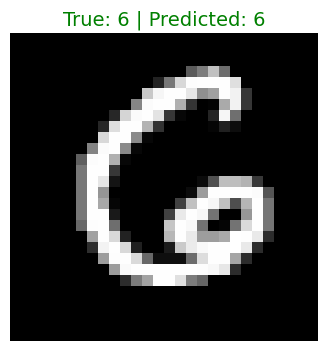

In [26]:
import matplotlib.pyplot as plt
import random

# 1. Pick a random image index from the 10,000 test images
random_index = random.randint(0, len(X_test) - 1)
test_image = X_test[random_index]
true_label = y_test[random_index]

# 2. Reshape the single image to match the format the model expects: (1, 28, 28, 1)
input_image = np.expand_dims(test_image, axis=0)

# 3. Get the model's prediction (probabilities for digits 0-9)
predictions = model.predict(input_image, verbose=0)

# 4. Use argmax to find the index with the highest probability
predicted_label = np.argmax(predictions[0])

# 5. Plot the image using Matplotlib
plt.figure(figsize=(4, 4))
# Squeeze out the extra color channel dimension for rendering (28, 28, 1 -> 28, 28)
plt.imshow(np.squeeze(test_image), cmap='gray')

# Change title color to green if correct, or red if incorrect
title_color = 'green' if predicted_label == true_label else 'red'
plt.title(f"True: {true_label} | Predicted: {predicted_label}", color=title_color, fontsize=14)

plt.axis('off') # Hide the pixel grid axes for a cleaner look
plt.show()


# Exercise 4: Custom Layer and Model
Problem Statement

Create:

1. Custom Layer:
  - Multiply input by 2
2. Create model using custom layer.
3. Pass sample input.
4. Verify output.
5. Print model summary.  

Solution

In [31]:
import tensorflow as tf

# 1. Define your custom layer
class DoubleLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return inputs * 2

# 2. Build the model architecture with a defined input structure
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)), # Tells Keras to expect 1 feature per row
    DoubleLayer()
])

# 3. Print the summary immediately (works perfectly now)
model.summary()

# 4. Define your testing tensor data
x = tf.constant([
    [1.0],
    [2.0],
    [3.0]
])

# 5. Run the data through the model and print outputs
print("\nModel Output:\n", model(x))


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ double_layer_4 (DoubleLayer)    │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Model Output:
 tf.Tensor(
[[2.]
 [4.]
 [6.]], shape=(3, 1), dtype=float32)


# Exercise 5: Custom Training Loop with GradientTape
Problem Statement

Build a simple linear regression model manually.

Tasks:

1. Create data:
- y = 3x + 2
2. Create trainable variables:
- Weight
- Bias
3. Use GradientTape.
4. Train for 100 epochs.
5. Print final weight and bias.  

Solution

In [34]:
import tensorflow as tf

X = tf.constant(
    [1.,2.,3.,4.,5.]
)

Y = tf.constant(
    [5.,8.,11.,14.,17.]
)

w = tf.Variable(0.0)
b = tf.Variable(0.0)

learning_rate = 0.01

for epoch in range(100):

    with tf.GradientTape() as tape:

        predictions = w * X + b

        loss = tf.reduce_mean(
            tf.square(
                Y - predictions
            )
        )

    gradients = tape.gradient(
        loss,
        [w,b]
    )

    w.assign_sub(
        learning_rate * gradients[0]
    )

    b.assign_sub(
        learning_rate * gradients[1]
    )

print("Weight:", w.numpy())
print("Bias:", b.numpy())

Weight: 3.2143393
Bias: 1.2261666


# **Advanced TensorFlow Mastery Checklist**

After completing these 5 exercises without looking at the solutions, you should understand:

1. **TensorFlow Core**
- Tensors
- Variables
- GradientTape
- Automatic Differentiation
2. **Keras**
- Sequential API
- Dense Layers
- Compile
- Fit
- Evaluate
- Predict
3. **Deep Learning**
- Regression
- Classification
- Activation Functions
- Loss Functions
- Optimizers
4. **CNN**
- Conv2D
- MaxPooling
- Flatten
- Softmax
5. **Advanced TensorFlow**
- Custom Layers
- Custom Models
- Custom Training Loops

# **Next Level: TensorFlow Project Challenge Set**

After these exercises, a strong progression is to build 5 complete projects:

1. House Price Prediction (Regression)
2. Customer Churn Prediction (Classification)
3. Handwritten Digit Recognition (CNN)
4. Sentiment Analysis (NLP)
5. Image Classification with Transfer Learning